In [8]:
import numpy as np
import matplotlib.pyplot as plt

# State encoding: 0=A(term), 1=B, 2=C, 3=D(start), 4=E, 5=F, 6=G(term)
START = 3
TRUE = np.array([1/6, 2/6, 3/6, 4/6, 5/6])   # values for B..F
np.random.seed(0)

## (c) TD(0) and constant-α MC implementations

In [9]:
def run_episode():
    s = START
    traj = []
    while True:
        s_next = s + np.random.choice([-1, 1])   # left/right
        r = 1.0 if s_next == 6 else 0.0          # +1 only into G
        traj.append((s, r, s_next))
        s = s_next
        if s == 0 or s == 6:                     # terminal
            break
    return traj

def rms_error(V):
    return np.sqrt(np.mean((V[1:6] - TRUE) ** 2))

def td0_prediction(n_episodes, alpha):
    V = np.full(7, 0.5); V[0] = 0.0; V[6] = 0.0    # terminals = 0
    errors = []
    for _ in range(n_episodes):
        for (s, r, s_next) in run_episode():
            V[s] += alpha * (r + V[s_next] - V[s])   # gamma = 1, TD(0) update
        errors.append(rms_error(V))
    return V, errors

def mc_prediction(n_episodes, alpha):
    V = np.full(7, 0.5); V[0] = 0.0; V[6] = 0.0
    errors = []
    for _ in range(n_episodes):
        traj = run_episode()
        G = sum(r for (_, r, _) in traj)   # gamma = 1: return from every visited state = total reward
        for (s, r, s_next) in traj:
            V[s] += alpha * (G - V[s])      # constant-alpha MC update
        errors.append(rms_error(V))
    return V, errors

# quick single-run sanity check (100 episodes)
V_td, e_td = td0_prediction(100, 0.1)
V_mc, e_mc = mc_prediction(100, 0.02)
print("TD(0)  V(B..F):", np.round(V_td[1:6], 3), " RMS:", round(e_td[-1], 4))
print("MC     V(B..F):", np.round(V_mc[1:6], 3), " RMS:", round(e_mc[-1], 4))
print("true   V(B..F):", np.round(TRUE, 3))

TD(0)  V(B..F): [0.122 0.317 0.536 0.743 0.91 ]  RMS: 0.0553
MC     V(B..F): [0.244 0.37  0.447 0.571 0.723]  RMS: 0.0795
true   V(B..F): [0.167 0.333 0.5   0.667 0.833]


## (d) RMS error vs. episodes

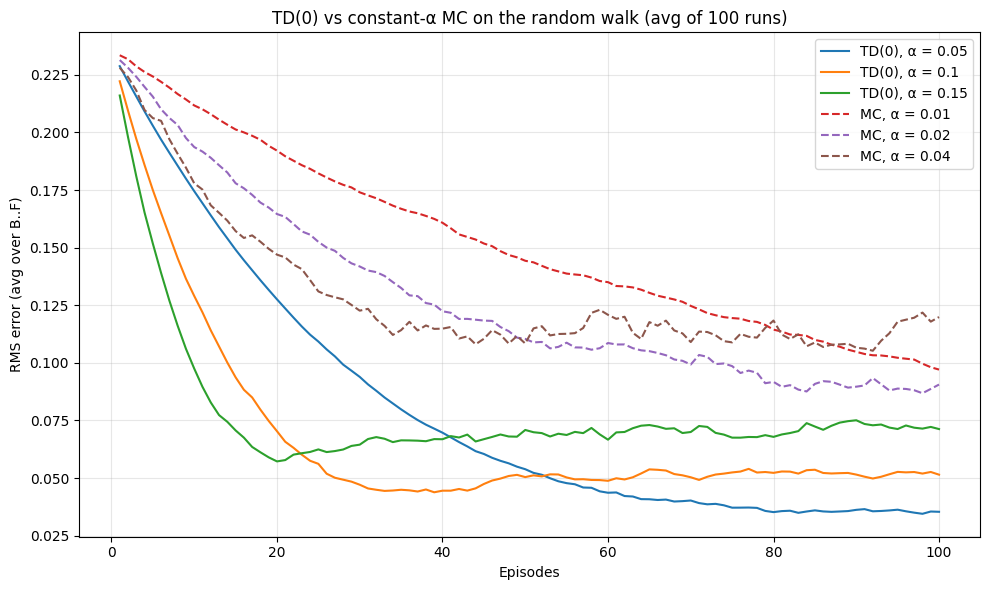

In [11]:
def averaged_curve(method, alpha, n_episodes=100, n_runs=100):
    all_errs = np.zeros((n_runs, n_episodes))
    for run in range(n_runs):
        _, errs = method(n_episodes, alpha)
        all_errs[run] = errs
    return all_errs.mean(axis=0)

N_EPISODES = 100
N_RUNS = 100                      # >= 50 as required
TD_ALPHAS = [0.05, 0.10, 0.15]
MC_ALPHAS = [0.01, 0.02, 0.04]

np.random.seed(42)
td_curves = {a: averaged_curve(td0_prediction, a, N_EPISODES, N_RUNS) for a in TD_ALPHAS}
mc_curves = {a: averaged_curve(mc_prediction,  a, N_EPISODES, N_RUNS) for a in MC_ALPHAS}

plt.figure(figsize=(10, 6))
for a in TD_ALPHAS:
    plt.plot(range(1, N_EPISODES + 1), td_curves[a],
             linestyle="-", label=f"TD(0), α = {a}")
for a in MC_ALPHAS:
    plt.plot(range(1, N_EPISODES + 1), mc_curves[a],
             linestyle="--", label=f"MC, α = {a}")
plt.xlabel("Episodes")
plt.ylabel("RMS error (avg over B..F)")
plt.title(f"TD(0) vs constant-α MC on the random walk (avg of {N_RUNS} runs)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("td_vs_mc_rms.png", dpi=120, bbox_inches="tight")
plt.show()